# Network Dynamics: Oscillation, Convergence, and Sequential Learning

Experiments on the dynamics of a recurrent network — oscillatory behavior, convergence to stable states, deterioration under noise, and sequential learning.

## SETTING

In [55]:
import numpy as np
import matplotlib.pyplot as plt

In [56]:
dim = 100
eps = 1/1000
eta = 1 - eps
num_pairs = [20, 40, 60, 80]
iteration = 500

In [57]:
np.random.seed(42)

In [58]:
def generate_randvec_normalized(dim): # d is the dimension of the vector
  randvec_zeromean = np.random.rand(dim) - 0.5
  randvec_normalized = randvec_zeromean / np.sqrt(np.sum(randvec_zeromean**2))
  return randvec_normalized

## Part (a): Oscillations

### IMPLEMENTATION

In [59]:
def create_dataset(dim, n_pairs):
    F = np.zeros((dim, n_pairs))
    G = np.zeros((dim, n_pairs))
    for i in range(n_pairs):
        F[:, i] = generate_randvec_normalized(dim)
        G[:, i] = generate_randvec_normalized(dim)
    return F, G

In [64]:
def train_widrow_hoff(f_vectors, g_vectors, mode, n_iterations=500):
    n_dim, n_patterns = f_vectors.shape
    W = np.zeros((n_dim, n_dim))
    error_history = []

    for j in range(1, n_iterations + 1):
        # pick random pair
        idx = np.random.randint(0, n_patterns)
        f = f_vectors[:, idx:idx+1]
        g = g_vectors[:, idx:idx+1]

        # output and error
        g_prime = W @ f
        error_vector = g - g_prime

        f_sq = np.dot(f.T, f).item()

        # decide learning rate
        if mode == 'constant1':
            lr = 0.1
        elif mode == 'constant2':
            lr = eta # 1 - eps
        elif mode == 'decreasing':
            lr = ((1.0 / f_sq) - eps) / j
        elif mode == 'explosive':
            lr = 2.5

        # D. update matrix
        W += lr * np.dot(error_vector, f.T)

        # avg error
        if j % 10 == 0:
            all_g_prime = W @ f_vectors
            all_errors = g_vectors - all_g_prime
            avg_err = np.mean(all_errors**2)
            error_history.append(avg_err)

    return error_history

### Outputs

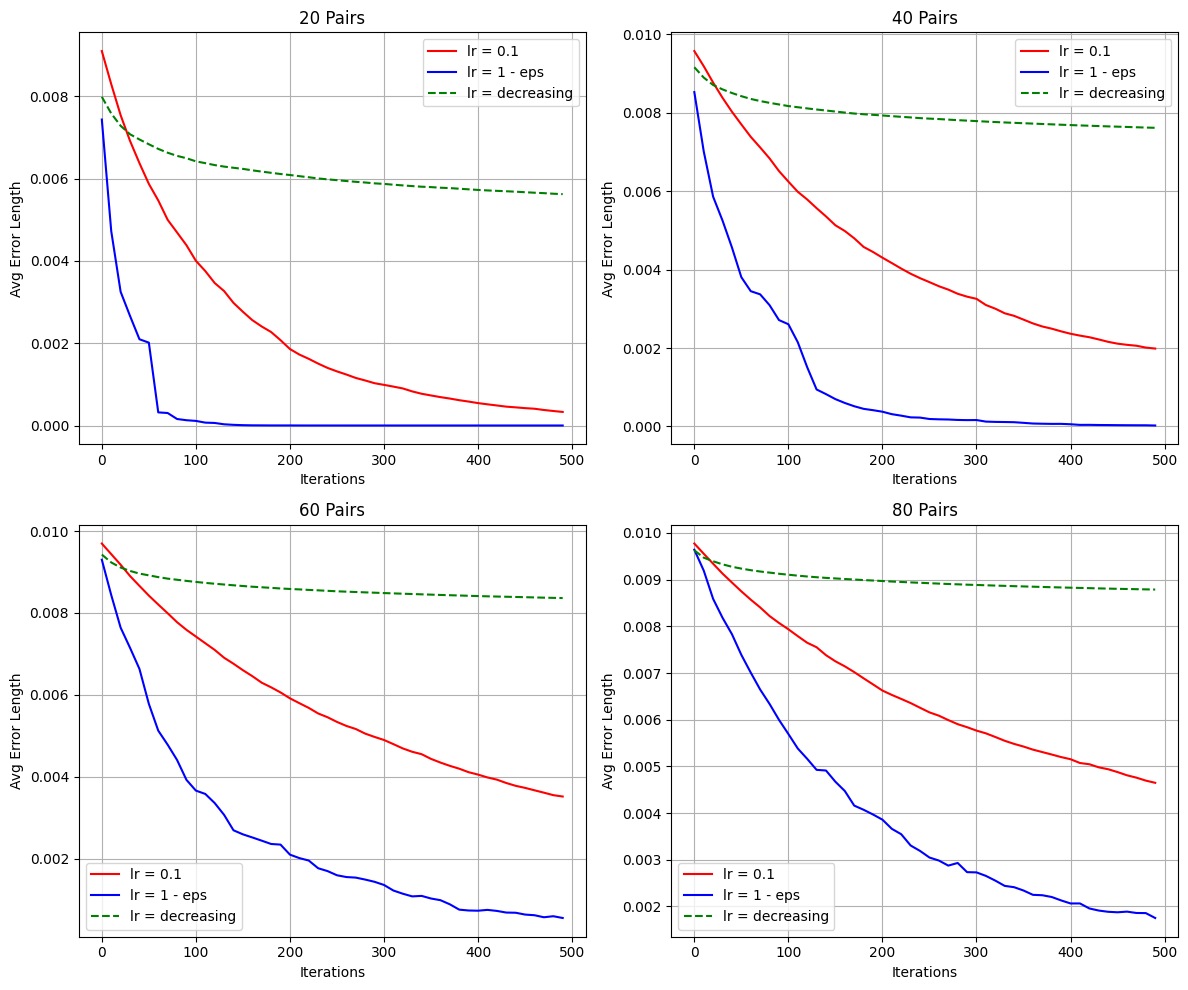

In [63]:
plt.figure(figsize=(12, 10))
plot_idx = 1

for n in num_pairs:
    F_set, G_set = create_dataset(dim, n)

    # Case 1: Constant 0.1
    err_1 = train_widrow_hoff(F_set, G_set, 'constant1')

    # Case 2: Constant (1 - epsilon)
    err_2 = train_widrow_hoff(F_set, G_set, 'constant2')

    # Case 3: Decreasing
    err_3 = train_widrow_hoff(F_set, G_set, 'decreasing')

    # plot
    plt.subplot(2, 2, plot_idx)
    x_axis = range(0, 500, 10)

    plt.plot(x_axis, err_1, 'r-', label='lr = 0.1')
    plt.plot(x_axis, err_2, 'b-', label='lr = 1 - eps')
    plt.plot(x_axis, err_3, 'g--', label='lr = decreasing')

    plt.title(f"{n} Pairs")
    plt.xlabel("Iterations")
    plt.ylabel("Avg Error Length")
    plt.legend()
    plt.grid(True)
    plot_idx += 1

plt.tight_layout()
plt.show()

### ANALYSIS

A large learning rate causes oscillation or blowup because the weight update step gets too aggressive. Instead of reducing the error, the correction shoots past the target, creating an even larger error on the opposite side, which is also called overshooting, and this leads to a cycle of growing instability. There is a possibility the value goes back and forth repetitively and not narrowing down to the target value.

Tapering the learning rate helps solve this by starting with large steps to learn quickly when error is high, then gradually shrinking the step size to dampen the interference between different patterns, allowing the weights to settle precisely into the minimum error solution without bouncing around.

Theoretical oscillations were not observed in this specific trial because the input vectors were normalized to length 1. If unnormalized vectors (length > 1) had been used with $\eta=1$, the system would have exceeded the stability threshold ($\eta > 2/|f|^2$) and oscillated/diverged. If we try with a bigger number, like below, we can see it blowing up.

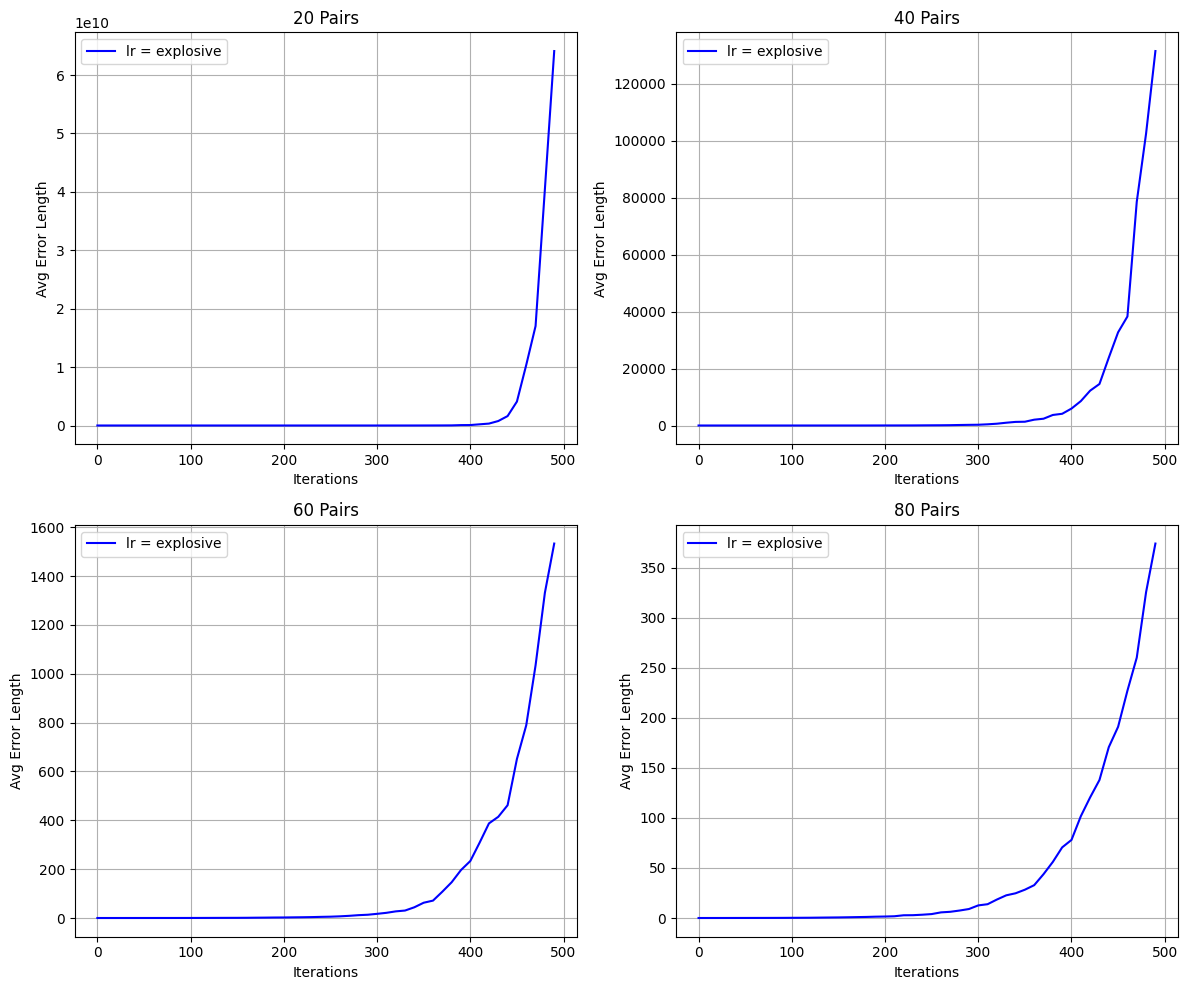

In [69]:
plt.figure(figsize=(12, 10))
plot_idx = 1
for n in num_pairs:
    F_set, G_set = create_dataset(dim, n)

    err_4 = train_widrow_hoff(F_set, G_set, 'explosive')

    # plot
    plt.subplot(2, 2, plot_idx)
    x_axis = range(0, 500, 10)
    plt.plot(x_axis, err_4, 'b-', label='lr = explosive')

    plt.title(f"{n} Pairs")
    plt.xlabel("Iterations")
    plt.ylabel("Avg Error Length")
    plt.legend()
    plt.grid(True)
    plot_idx +=1

plt.tight_layout()
plt.show()

## Part (b): Convergence

### IMPLEMENTATION

In [73]:
def train_until_convergence(f_vectors, g_vectors, tolerance=0.000001, max_iter=20000):

    n_dim, n_patterns = f_vectors.shape
    W = np.zeros((n_dim, n_dim))

    lr = eta

    iteration_count = 0

    while iteration_count < max_iter:
        iteration_count += 1

        idx = np.random.randint(0, n_patterns)
        f = f_vectors[:, idx:idx+1]
        g = g_vectors[:, idx:idx+1]

        g_prime = W @ f
        error_vector = g - g_prime
        W += lr * np.dot(error_vector, f.T)

        if iteration_count % 100 == 0:
            all_g_prime = W @ f_vectors
            all_errors = g_vectors - all_g_prime

            current_mse = np.mean(all_errors**2)

            if current_mse < tolerance:
                return iteration_count

    print(f"Did not converge for {n_patterns} pairs.")
    return iteration_count

### Outputs

In [74]:
convergence_results = []
n_trials = 10

print(f"Running Convergence Tests (Averaging over {n_trials} trials)...")

for n in num_pairs:
    total_iters = 0

    for t in range(n_trials):
        F_set, G_set = create_dataset(dim, n)

        iters = train_until_convergence(F_set, G_set)
        total_iters += iters

    avg_iters = total_iters / n_trials
    convergence_results.append(avg_iters)
    print(f"Pairs: {n} -> Avg Iterations: {avg_iters:.1f}")

Running Convergence Tests (Averaging over 10 trials)...
Pairs: 20 -> Avg Iterations: 220.0
Pairs: 40 -> Avg Iterations: 930.0
Pairs: 60 -> Avg Iterations: 3010.0
Pairs: 80 -> Avg Iterations: 16030.0


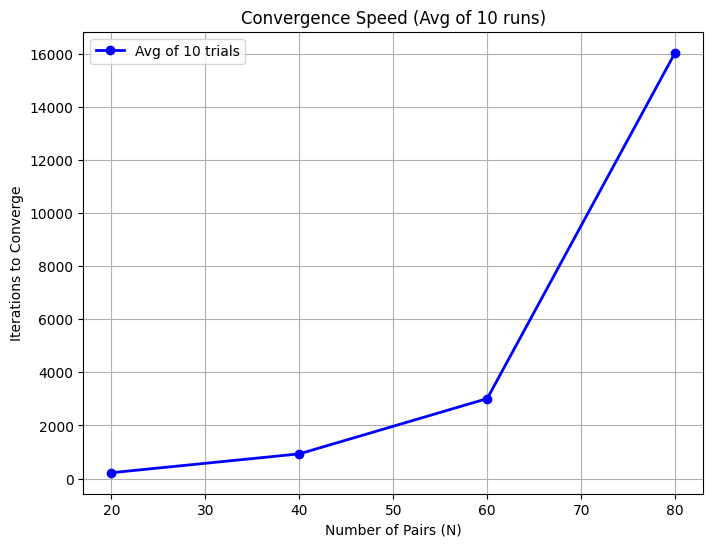

In [75]:
plt.figure(figsize=(8, 6))
plt.plot(num_pairs, convergence_results, 'bo-', linewidth=2, label=f'Avg of {n_trials} trials')
plt.title(f"Convergence Speed (Avg of {n_trials} runs)")
plt.xlabel("Number of Pairs (N)")
plt.ylabel("Iterations to Converge")
plt.legend()
plt.grid(True)
plt.show()

### STOPPING CRITERION

The stopping rule is if the Mean Squared Error (MSE) goes under 0.000001, which is expressed as tolerance in the code. This criterion is sensible because it checks if the MSE is in meaningfully low to say it is converging, and then decides to stop, not stopping by a fixed number of iterations. If it is a fixed number, it will stop iterating no matter how earlier the MSE became meaningfully low or no matter how high it is. However, the method I chose makes sure it has a meaninfully low MSE to say it is converging. Then, it gives the number of iterations it took to get there. The number is strict enough to have a precise classification, but also not too strict to prevent the code going on forever to find an absolute 0.

This improved a lot from the linear associator from HW2 because it adjusts weights continuously until interference is removed. This is an accuracy HW2 linear associator cannot reach, as the linear associator is only one-shot.

## Part (c): Deterioration

### IMPLEMENTATION

In [76]:
def train_fixed_iterations(f_vectors, g_vectors, iterations=2000):
    n_dim, n_patterns = f_vectors.shape
    W = np.zeros((n_dim, n_dim))
    lr = eta

    for j in range(iterations):
        idx = np.random.randint(0, n_patterns)
        f = f_vectors[:, idx:idx+1]
        g = g_vectors[:, idx:idx+1]

        g_prime = W @ f
        error = g - g_prime
        W += lr * np.dot(error, f.T)

    return W

### Outputs

In [77]:
num_pairs_extra = [100, 150, 200, 250, 300, 500]
avg_cos = []
avg_mse = []

print("Running Capacity Deterioration Test...")

for n in num_pairs_extra:
    trial_cos = []
    trial_mse = []

    for t in range(10):
        F, G = create_dataset(dim, n)

        W = train_fixed_iterations(F, G, iterations=n*50)

        G_prime = W @ F

        cos_sims = []
        for i in range(n):
            g_target = G[:, i]
            g_actual = G_prime[:, i]

            norm_actual = np.linalg.norm(g_actual)
            if norm_actual > 0:
                cos = np.dot(g_target, g_actual) / (norm_actual * 1.0)
            else:
                cos = 0
            cos_sims.append(cos)

        trial_cos.append(np.mean(cos_sims))

        errors = G - G_prime
        mse = np.mean(errors**2)
        trial_mse.append(mse)

    avg_cos.append(np.mean(trial_cos))
    avg_mse.append(np.mean(trial_mse))
    print(f"Pairs: {n} -> Avg Cosine: {avg_cos[-1]:.3f} | MSE: {avg_mse[-1]:.3f}")

Running Capacity Deterioration Test...
Pairs: 100 -> Avg Cosine: 0.944 | MSE: 0.001
Pairs: 150 -> Avg Cosine: 0.679 | MSE: 0.007
Pairs: 200 -> Avg Cosine: 0.514 | MSE: 0.010
Pairs: 250 -> Avg Cosine: 0.411 | MSE: 0.012
Pairs: 300 -> Avg Cosine: 0.340 | MSE: 0.013
Pairs: 500 -> Avg Cosine: 0.204 | MSE: 0.016


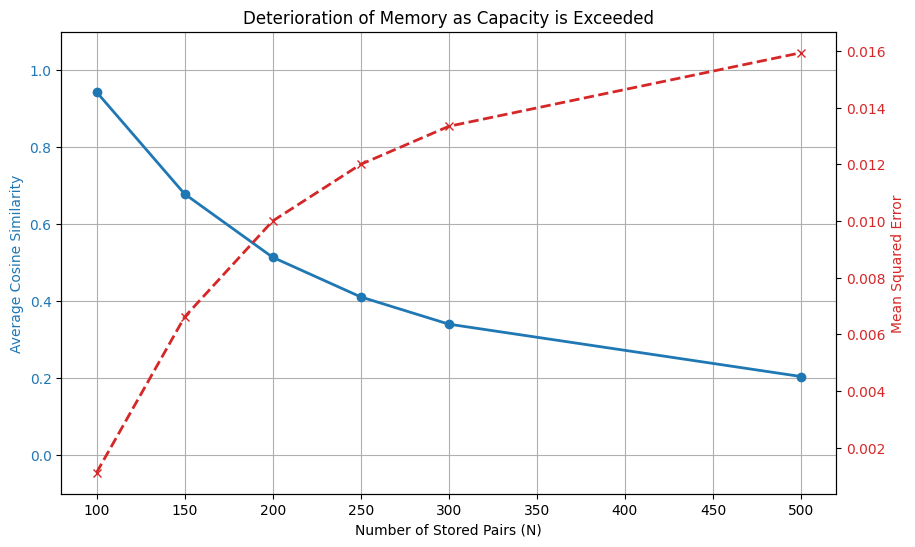

In [78]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Stored Pairs (N)')
ax1.set_ylabel('Average Cosine Similarity', color=color)
ax1.plot(num_pairs_extra, avg_cos, 'o-', color=color, linewidth=2, label='Cosine Sim (Quality)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-0.1, 1.1)
ax1.grid(True)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Squared Error', color=color)  # we already handled the x-label with ax1
ax2.plot(num_pairs_extra, avg_mse, 'x--', color=color, linewidth=2, label='MSE (Error)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Deterioration of Memory as Capacity is Exceeded")
plt.show()

### ANALYSIS

Breakdown happens when the system associates the input vector f with the target g no better than a random occurence. In high-dimensional space, two random vectors being orthogonal is a high possibility. Therefore, a random occurence of a cosine value of two vectors corresponds to a cosine similarity of 0. In our graph, we see the cosine similarity drop steadily. A "total breakdown" is when the curve flattens out near 0.

The Hebbian rule breaks down suddenly due to crosstalk as soon as orthogonality is lost, the Widrow-Hoff rule minimizes the squared error, preserving the best possible direction of the output by distributign the error even when the capacity is exceeded (N > 100). Based on our results, the system stores up to 100 associations with high fidelity (cosine value being over 0.9) before significant breakdown starts.

## Part (d): Sequential Learning

### IMPLEMENTATION

In [83]:
def train_variable_order(f_vectors, g_vectors, mode='random', tolerance=0.000001, max_iter=20000):
    n_dim, n_patterns = f_vectors.shape
    W = np.zeros((n_dim, n_dim))
    lr = 1.0

    current_idx = 0

    for iteration_count in range(1, max_iter + 1):

        if mode == 'random':
            idx = np.random.randint(0, n_patterns)

        elif mode == 'forward':
            idx = current_idx
            current_idx = (current_idx + 1) % n_patterns

        elif mode == 'backward':
            idx = current_idx
            current_idx = (current_idx - 1 + n_patterns) % n_patterns

        f = f_vectors[:, idx:idx+1]
        g = g_vectors[:, idx:idx+1]

        g_prime = W @ f
        error_vec = g - g_prime
        W += lr * np.dot(error_vec, f.T)

        if iteration_count % n_patterns == 0:
            all_g_prime = W @ f_vectors
            all_errors = g_vectors - all_g_prime
            mse = np.mean(all_errors**2)

            if mse < tolerance:
                return iteration_count

    return max_iter

### Outputs

In [84]:
modes = ['random', 'forward', 'backward']

results = {mode: [] for mode in modes}

print("Running Sequential vs Random Comparison...")

for n in num_pairs:
    print(f"\nTesting N = {n}...")

    for mode in modes:
        total_iters = 0
        n_trials = 10

        for t in range(n_trials):
            F, G = create_dataset(dim, n)
            iters = train_variable_order(F, G, mode=mode, max_iter=20000)
            total_iters += iters

        avg_iter = total_iters / n_trials
        results[mode].append(avg_iter)
        print(f"  Mode: {mode:10s} -> Avg Iterations: {avg_iter:.1f}")

Running Sequential vs Random Comparison...

Testing N = 20...
  Mode: random     -> Avg Iterations: 226.0
  Mode: forward    -> Avg Iterations: 100.0
  Mode: backward   -> Avg Iterations: 100.0

Testing N = 40...
  Mode: random     -> Avg Iterations: 852.0
  Mode: forward    -> Avg Iterations: 436.0
  Mode: backward   -> Avg Iterations: 392.0

Testing N = 60...
  Mode: random     -> Avg Iterations: 2934.0
  Mode: forward    -> Avg Iterations: 1482.0
  Mode: backward   -> Avg Iterations: 1404.0

Testing N = 80...
  Mode: random     -> Avg Iterations: 15352.0
  Mode: forward    -> Avg Iterations: 7504.0
  Mode: backward   -> Avg Iterations: 7952.0


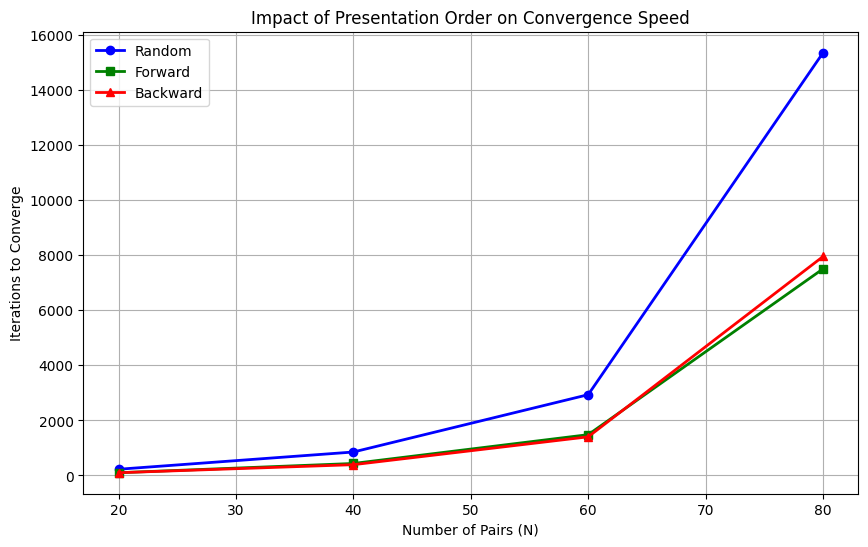

In [85]:
plt.figure(figsize=(10, 6))

markers = {'random': 'o-', 'forward': 's-', 'backward': '^-'}
colors = {'random': 'blue', 'forward': 'green', 'backward': 'red'}

for mode in modes:
    plt.plot(num_pairs, results[mode], markers[mode],
             color=colors[mode], linewidth=2, label=f'{mode.capitalize()}')

plt.title("Impact of Presentation Order on Convergence Speed")
plt.xlabel("Number of Pairs (N)")
plt.ylabel("Iterations to Converge")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
print("--- Linear Associator (Hebbian) Order Check ---")
F, G = create_dataset(dim, 40)

# forward sum
W_fwd = np.zeros((dim, dim))
for i in range(40):
    W_fwd += np.outer(G[:, i], F[:, i])

# backward sum
W_bwd = np.zeros((dim, dim))
for i in range(39, -1, -1):
    W_bwd += np.outer(G[:, i], F[:, i])

# compare
diff = np.sum((W_fwd - W_bwd)**2)
print(f"Squared Difference between Forward and Backward Hebbian Matrices: {diff:.10f}")
if diff < 1e-9:
    print("Conclusion: The Linear Associator is COMPLETELY order-invariant.")
else:
    print("Conclusion: Order matters (Unexpected).")

--- Linear Associator (Hebbian) Order Check ---
Squared Difference between Forward and Backward Hebbian Matrices: 0.0000000000
Conclusion: The Linear Associator is COMPLETELY order-invariant.


### ANALYSIS

We can see the learning of forward and backward, so the sequential presentation, is faster than that of the random presentation. This shows better as the number of pairs increase.

The Widrow-Hoff is relatively robust to presentation order. There is a speed difference, because it can possibly learn the pattern of randomness, therefore predict the future, so converge faster than random presentation. However, it eventually converges, no matter what the presentation order is as it slowly learns with the learning rate, and comes to a certain convergence.

The linear associator is completely order-invariant because it is one-shot. It is just adding the matrices, so the order does not matter, as order is not important for matrix addition.